# Data Wrangling:
                Data wrangling is the process of cleaning, organizing, and transforming raw data into a usable format for analysis or decision-making.

## Steps:
1. Gathering data(kia) libraries 
2. Tools to clean data (kis se clean) libraries
3. How to do kaisey (steps)

In [49]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df= sns.load_dataset('titanic')

In [51]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [52]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [54]:
df.isnull().sum() / len(df) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [55]:
df.drop(columns=['deck'], inplace=True)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [57]:
df['age'] = df['age'].fillna(df['age'].mean())


In [58]:
df.isnull().sum() / len(df) * 100

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.000000
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.224467
class          0.000000
who            0.000000
adult_male     0.000000
embark_town    0.224467
alive          0.000000
alone          0.000000
dtype: float64

In [59]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [60]:
df.isnull().sum() / len(df) * 100

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.000000
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.000000
class          0.000000
who            0.000000
adult_male     0.000000
embark_town    0.224467
alive          0.000000
alone          0.000000
dtype: float64

In [61]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

In [62]:
df.isnull().sum() / len(df) * 100

survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
embark_town    0.0
alive          0.0
alone          0.0
dtype: float64

# Outliers Removal

## Visulization wala method

<Axes: xlabel='sex', ylabel='age'>

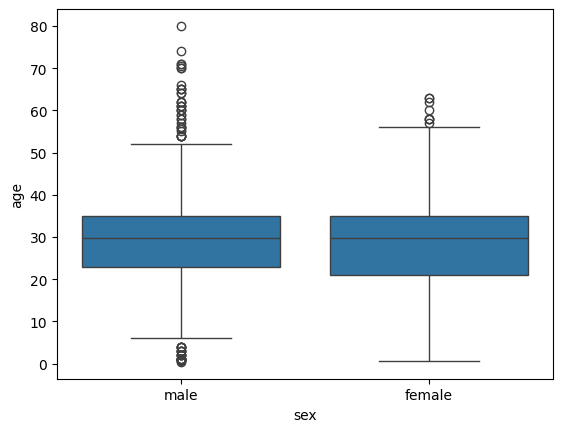

In [63]:
import seaborn as sns
sns.boxplot(data=df, y='age', x='sex')

In [64]:
# IQR method to remove outliers
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
IQR 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR    
df = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

In [17]:
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR    
# df = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

In [65]:
df.shape

(825, 14)

In [66]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
IQR 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR    
df = df[(df['fare'] >= lower_bound) & (df['fare'] <= upper_bound)]

In [67]:
df.shape

(718, 14)

<Axes: xlabel='age', ylabel='Count'>

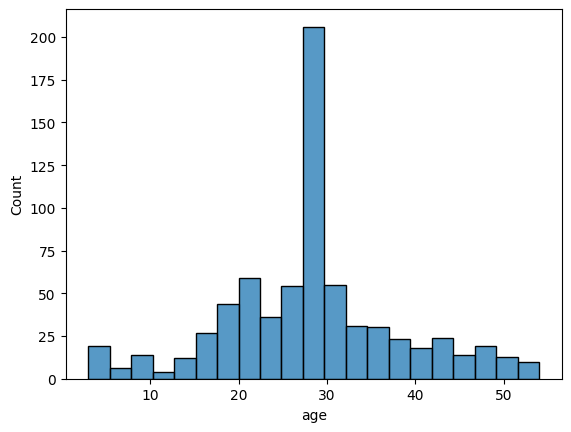

In [68]:
sns.histplot(df['age'])

In [69]:
# Z-score method to remove outliers
from scipy import stats
import numpy as np
zscores = np.abs(stats.zscore(df['age']))
threshold = 3
df = df[zscores < threshold].all(axis=1)

# Finding and Droppings Duplicates

In [70]:
df.shape

(718,)

In [71]:
# finding and removing duplicates
# find duplicates
df.duplicated().sum()

np.int64(717)

In [72]:
df_duplicates = df[df.duplicated()]
df_duplicates.head()

2    False
3    False
4    False
5    False
6    False
dtype: bool

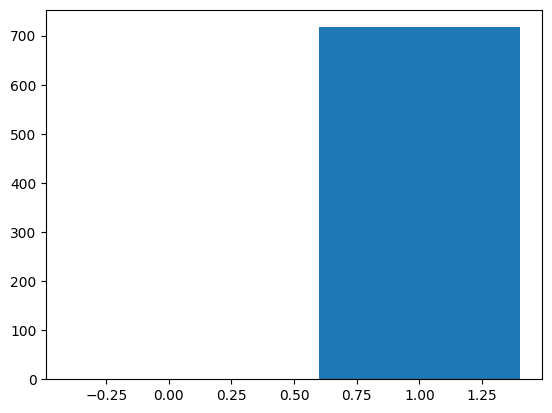

In [73]:
df_duplicates = df.duplicated()
df_duplicates_count = df_duplicates.value_counts()

plt.bar(df_duplicates_count.index,df_duplicates_count.values)
plt.show()

In [74]:
df.drop_duplicates(inplace=True)

# Data normalization 

In [75]:
#import libraries 
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 2. data 
df

# select columns to normalize 
cols_to_normalize = ['age','fare']

# 4. create the scaler function/tools 
scaler = MinMaxScaler()

#5.Fit and transform the data on scaler or vice versa
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

#6. check the data 
df 


KeyError: "None of [Index(['age', 'fare'], dtype='object')] are in the [index]"

In [76]:
df.describe()

count         1
unique        1
top       False
freq          1
dtype: object

In [77]:
#import libraries 
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 2. data 
df

# select columns to normalize 
cols_to_normalize = ['age','fare']

# 4. create the scaler function/tools 
scaler = StandardScaler()

#5.Fit and transform the data on scaler or vice versa
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

#6. check the data 
df 


KeyError: "None of [Index(['age', 'fare'], dtype='object')] are in the [index]"

x_stand = (x - mean(x)) / std(x)

where:

x_stand is the standarized variable
x is the original variable
mean(x) is the mean of the variable x
std(x) is the standarad deviation of variable x 

# Log Transforamtion

In [78]:
kashti = sns.load_dataset('titanic')
kashti.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [37]:
import numpy as np

kashti['age'] = kashti['age'].fillna(kashti['age'].median())
kashti['fare']= kashti['fare'].fillna(kashti['fare'].median())

# log transform
kashti ['age'] = np.log(kashti['age'])
kashti ['fare']= np.log(kashti['fare'])
kashti.head()

c:\Users\MARWAT LAPTOP\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,3.091042,1,0,1.981001,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,3.637586,1,0,4.266662,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,3.258097,0,0,2.070022,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,3.555348,1,0,3.972177,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,3.555348,0,0,2.085672,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='sex', ylabel='fare'>

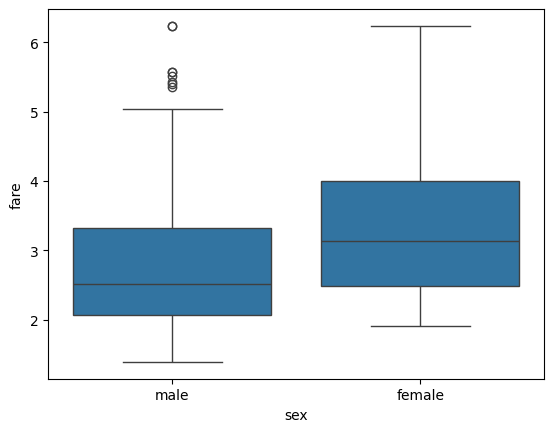

In [38]:
sns.boxplot(data=kashti, x='sex', y='fare')

<Axes: xlabel='age', ylabel='Count'>

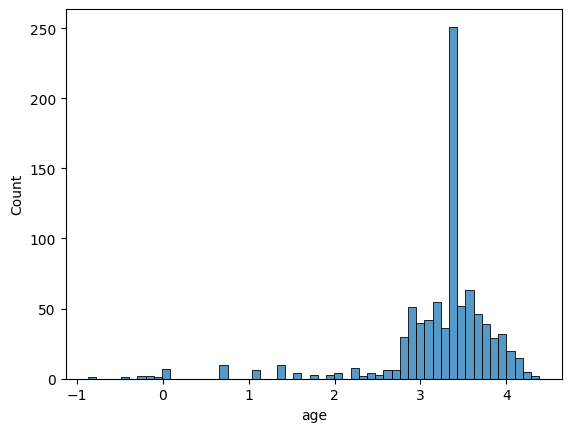

In [39]:
sns.histplot(kashti['age'])

In [79]:
df = kashti

In [80]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

# Organizing the data 

In [81]:
kashti['family_size'] = kashti['sibsp'] + kashti['parch']

<Axes: xlabel='family_size', ylabel='Count'>

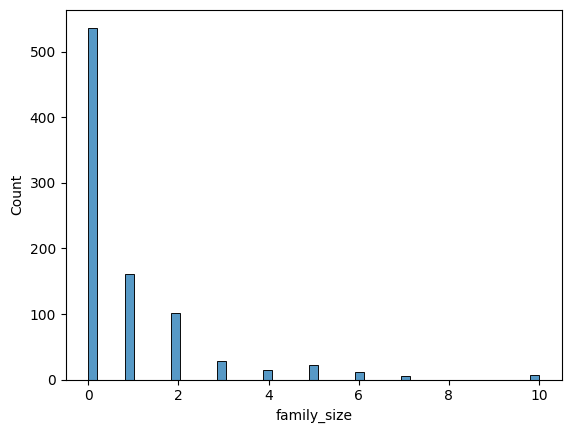

In [83]:
sns.histplot(df['family_size'])

In [85]:
df = df.rename(columns={'survived': 'survival'})
df.columns  

Index(['survival', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'family_size'],
      dtype='object')

In [86]:
table = pd.pivot_table(df,values='fare', index = 'pclass',
                       columns='survival', aggfunc=np.sum)
table

C:\Users\MARWAT LAPTOP\AppData\Local\Temp\ipykernel_15088\1695441868.py:1: FutureWarning: The provided callable <function sum at 0x00000185AF0507D0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = pd.pivot_table(df,values='fare', index = 'pclass',


survival,0,1
pclass,,
1,5174.7206,13002.6919
2,1882.9958,1918.8459
3,5085.0035,1629.6916


<Axes: xlabel='fare', ylabel='age'>

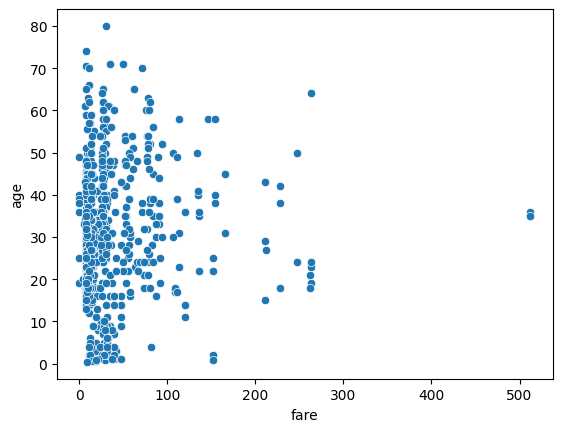

In [87]:
sns.scatterplot(data =df , x = 'fare', y = 'age')

In [88]:
kashti['family_size'] = kashti['sibsp'] + kashti['parch']

In [89]:
df.head()

,survival,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


# Saving the wrangled data 

In [90]:
df.to_csv('preprocessed_data.csv')